# 13c -- Rolling 6-month OOS windows

**Цель:** честная оценка V13a в разных периодах рынка, не только на main.

**Контекст:**
- Main period (2021-01..2025-09) — где Optuna тюнила CatBoost, filter thresholds выбирались
- Clean holdout (2025-10..2026-03) — strict OOS
- На clean holdout V13a проиграл всем ETFs (bull market без stress)

**Гипотеза:** результат регим-зависимый. Стратегия работает в normal/volatile periods, проигрывает в pure bull.

**Проверка:** разбиваем доступные данные на 6-месячные windows, оцениваем V13a vs 3 ETFs в каждой.

**Windows:**
| ID | Период | Тип | Что в нём |
|---|---|---|---|
| W1 | 2021-07..2021-12 | semi-OOS | спокойный pre-СВО |
| W2 | 2022-01..2022-06 | semi-OOS | СВО, шок |
| W3 | 2022-07..2022-12 | semi-OOS | recovery после шока |
| W4 | 2023-01..2023-06 | semi-OOS | стабилизация |
| W5 | 2023-07..2023-12 | semi-OOS | high rates |
| W6 | 2024-01..2024-06 | semi-OOS | high rates |
| W7 | 2024-07..2024-12 | semi-OOS | пик ставки |
| W8 | 2025-01..2025-06 | semi-OOS | recent past |
| W9 | 2025-07..2025-12 | mixed | partly clean holdout |
| **W10** | **2025-10..2026-03** | **CLEAN OOS** | strict holdout |

## Часть 1. Setup и вычисление V13a returns на full period

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Reproduce V13a on FULL period
sig = sl.load_signal_full('no_lag')
sig_wl = sl.load_signal_full('with_lag')
wl_sub = sig_wl[['date', 'isin', 'mispricing_z']].copy()
wl_sub.columns = ['date', 'isin', 'mispricing_z_wl']
sig = sig.merge(wl_sub, on=['date', 'isin'], how='inner')
sig['mispricing_z_nl'] = sig['mispricing_z']
sig['mispricing_avg_z'] = (sig['mispricing_z_nl'] + sig['mispricing_z_wl']) / 2
sig = sl.compute_quality_score(sig)

# V11e backtest на FULL period
mask = sig['quality_z'] > 0
rets_v11e, _ = sl.backtest_rule_c(sig, n_max=25, freq='Q', ranking_col='mispricing_avg_z',
                                    filter_mask=mask, sizing='z_weighted')

# V13a overlay
macro = pd.read_csv(sl.DATA_DIR / 'macro.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
macro['rvi_p90'] = macro['rvi'].rolling(252, min_periods=60).quantile(0.90)
macro['s1'] = (macro['rvi'] > macro['rvi_p90']).fillna(False).astype(int)
macro['s2'] = (macro['key_rate'].diff(5).abs() > 2.0).fillna(False).astype(int)
macro['s3'] = (macro['imoex_close'].pct_change(5) < -0.10).fillna(False).astype(int)
macro['s4'] = (macro['rvi'] > 50).astype(int)
macro['stress_idx'] = macro['s1'] + macro['s2'] + macro['s3'] + macro['s4']
macro['regime'] = np.where(macro['stress_idx'] >= 2, 'stress', 'normal')
regime_df = macro[['date', 'regime']]
rets_v13a = rets_v11e.merge(regime_df, on='date', how='left')
rets_v13a['regime'] = rets_v13a['regime'].fillna('normal')
rets_v13a['return'] = np.where(rets_v13a['regime'] == 'stress', 0.0, rets_v13a['return'])
rets_v13a = rets_v13a[['date', 'return', 'n_positions']]

print(f'V11e: {len(rets_v11e)} days')
print(f'V13a: {len(rets_v13a)} days, stress days {(macro["regime"] == "stress").sum()}')

V11e: 1241 days
V13a: 1241 days, stress days 138


## Часть 2. Define windows и compute per-window metrics

In [2]:
windows = [
    ('W1 2021-H2',  pd.Timestamp('2021-07-01'), pd.Timestamp('2021-12-31'), 'pre-СВО спокойный'),
    ('W2 2022-H1',  pd.Timestamp('2022-01-01'), pd.Timestamp('2022-06-30'), 'СВО шок'),
    ('W3 2022-H2',  pd.Timestamp('2022-07-01'), pd.Timestamp('2022-12-31'), 'recovery'),
    ('W4 2023-H1',  pd.Timestamp('2023-01-01'), pd.Timestamp('2023-06-30'), 'стабилизация'),
    ('W5 2023-H2',  pd.Timestamp('2023-07-01'), pd.Timestamp('2023-12-31'), 'high rates'),
    ('W6 2024-H1',  pd.Timestamp('2024-01-01'), pd.Timestamp('2024-06-30'), 'high rates'),
    ('W7 2024-H2',  pd.Timestamp('2024-07-01'), pd.Timestamp('2024-12-31'), 'пик ставки'),
    ('W8 2025-H1',  pd.Timestamp('2025-01-01'), pd.Timestamp('2025-06-30'), 'recent past'),
    ('W9 2025-Q3',  pd.Timestamp('2025-07-01'), pd.Timestamp('2025-09-30'), 'last quarter Main'),
    ('W10 HOLDOUT', pd.Timestamp('2025-10-01'), pd.Timestamp('2026-03-30'), 'CLEAN OOS'),
]

etfs = pd.read_csv(sl.DATA_DIR / 'etfs.csv', parse_dates=['date'])
bench = sl.load_benchmarks()

def metrics_for_window(rets_df, start, end, name='', is_strategy=True):
    sub = rets_df[(rets_df['date'] >= start) & (rets_df['date'] <= end)].copy()
    if len(sub) < 5:
        return None
    if not is_strategy:
        sub['n_positions'] = 1
    m = sl.calc_metrics(sub, name=name)
    return m

rows = []
for label, start, end, regime in windows:
    # V13a
    m = metrics_for_window(rets_v13a, start, end, 'V13a')
    if m is None:
        continue
    base = {'window': label, 'regime': regime, 'days': m['n_days'],
            'strategy': 'V13a',
            'Sharpe': m['Sharpe'], 'CAGR': m['CAGR'],
            'profit_RUB': m['profit_RUB'], 'MaxDD': m['MaxDD']}
    rows.append(base)
    # ETFs
    for etf, col in [('OBLG', 'oblg_ret'), ('SBRB', 'sbrb_ret'), ('TBRU', 'tbru_ret')]:
        et_df = etfs[['date', col]].dropna().rename(columns={col: 'return'})
        m = metrics_for_window(et_df, start, end, etf, is_strategy=False)
        if m is None: continue
        rows.append({'window': label, 'regime': regime, 'days': m['n_days'],
                     'strategy': etf,
                     'Sharpe': m['Sharpe'], 'CAGR': m['CAGR'],
                     'profit_RUB': m['profit_RUB'], 'MaxDD': m['MaxDD']})

df = pd.DataFrame(rows)
print('Per-window summary:')
for label, _, _, regime in windows:
    sub = df[df['window'] == label]
    if sub.empty: continue
    print(f'\n{label}  ({regime})  days={sub.iloc[0]["days"]}')
    sub_disp = sub[['strategy', 'Sharpe', 'CAGR', 'profit_RUB']].round(3)
    print(sub_disp.to_string(index=False))

Per-window summary:

W1 2021-H2  (pre-СВО спокойный)  days=130
strategy  Sharpe   CAGR  profit_RUB
    V13a   0.640  0.018   87992.626
    OBLG   0.241  0.007   34550.839
    SBRB   0.804  0.027  132119.264
    TBRU  -0.466 -0.013  -61839.218

W2 2022-H1  (СВО шок)  days=98
strategy  Sharpe   CAGR  profit_RUB
    V13a   4.467  0.278 1270460.916
    OBLG   0.475  0.068  324643.384
    SBRB   0.758  0.129  610925.008
    TBRU  -0.076 -0.068 -337213.970

W3 2022-H2  (recovery)  days=130
strategy  Sharpe  CAGR  profit_RUB
    V13a   2.581 0.151  726695.220
    OBLG   1.974 0.113  548184.176
    SBRB   2.130 0.142  685831.272
    TBRU   1.936 0.207  984628.168

W4 2023-H1  (стабилизация)  days=124
strategy  Sharpe  CAGR  profit_RUB
    V13a   4.284 0.100  477466.655
    OBLG   4.308 0.092  439724.798
    SBRB   3.669 0.098  465394.747
    TBRU   3.064 0.104  495461.422

W5 2023-H2  (high rates)  days=130
strategy  Sharpe   CAGR  profit_RUB
    V13a  -0.452 -0.018  -88729.631
    OBLG  -0.38

## Часть 3. Кто побеждает в каждом окне

In [3]:
# Wins / losses analysis: для каждого окна — best Sharpe / best Profit
wins = []
for label, _, _, regime in windows:
    sub = df[df['window'] == label]
    if sub.empty: continue
    best_sharpe = sub.loc[sub['Sharpe'].idxmax()]
    best_profit = sub.loc[sub['profit_RUB'].idxmax()]
    v13a_row = sub[sub['strategy'] == 'V13a'].iloc[0]
    wins.append({
        'window': label, 'regime': regime,
        'V13a_Sharpe': v13a_row['Sharpe'],
        'V13a_profit': v13a_row['profit_RUB'],
        'best_Sharpe_winner': best_sharpe['strategy'],
        'best_Sharpe_value': best_sharpe['Sharpe'],
        'best_profit_winner': best_profit['strategy'],
        'best_profit_value': best_profit['profit_RUB'],
        'V13a_wins_Sharpe': best_sharpe['strategy'] == 'V13a',
        'V13a_wins_profit': best_profit['strategy'] == 'V13a',
    })
wins_df = pd.DataFrame(wins)
print('Wins matrix:')
print(wins_df.round(3).to_string(index=False))
print()
print(f'V13a wins on Sharpe: {wins_df["V13a_wins_Sharpe"].sum()} / {len(wins_df)} окон')
print(f'V13a wins on Profit: {wins_df["V13a_wins_profit"].sum()} / {len(wins_df)} окон')

Wins matrix:
     window            regime  V13a_Sharpe  V13a_profit best_Sharpe_winner  best_Sharpe_value best_profit_winner  best_profit_value  V13a_wins_Sharpe  V13a_wins_profit
 W1 2021-H2 pre-СВО спокойный        0.640    87992.626               SBRB              0.804               SBRB         132119.264             False             False
 W2 2022-H1           СВО шок        4.467  1270460.916               V13a              4.467               V13a        1270460.916              True              True
 W3 2022-H2          recovery        2.581   726695.220               V13a              2.581               TBRU         984628.168              True             False
 W4 2023-H1      стабилизация        4.284   477466.655               OBLG              4.308               TBRU         495461.422             False             False
 W5 2023-H2        high rates       -0.452   -88729.631               TBRU              1.045               TBRU         252252.252             Fal

## Часть 4. Визуализация — Sharpe по окнам

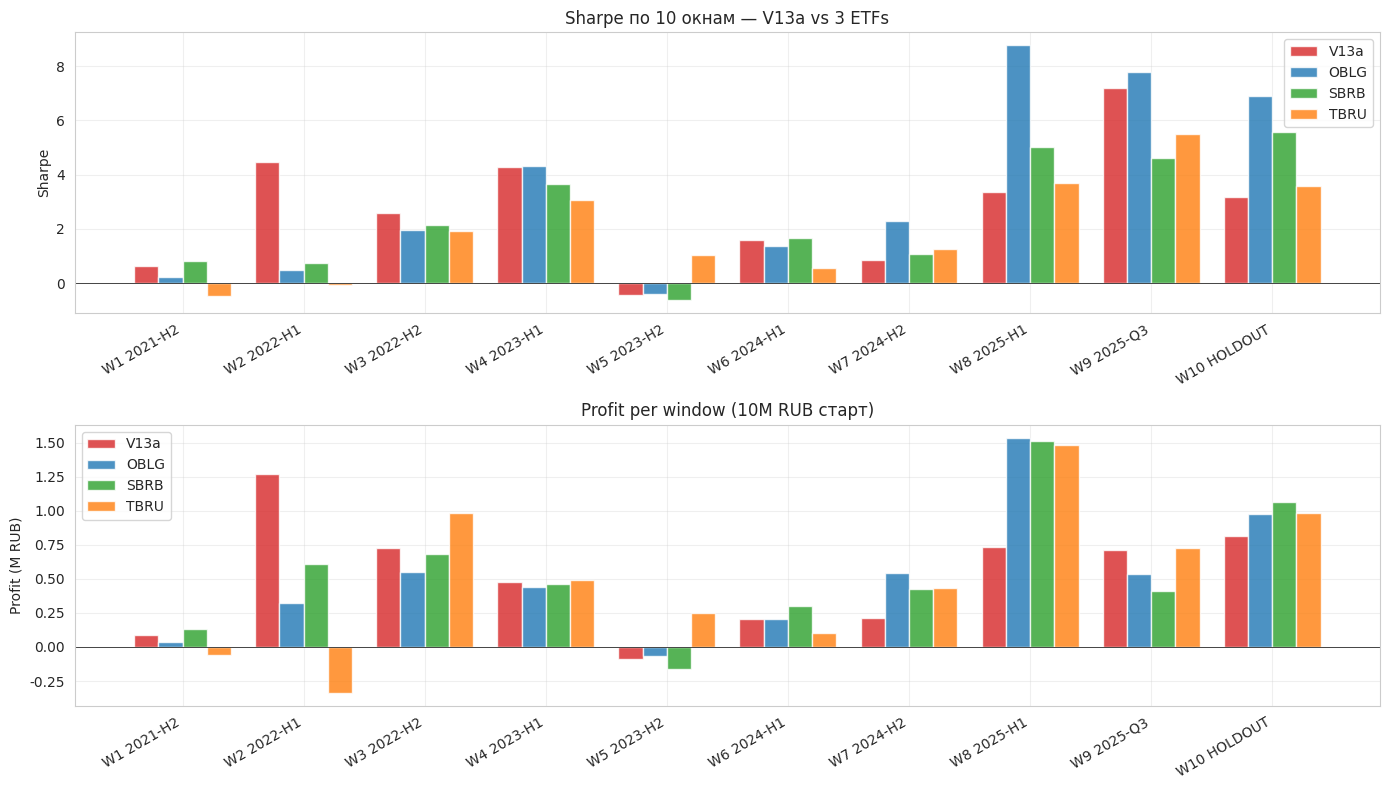

In [4]:
import matplotlib.cm as cm
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

win_labels = [w[0] for w in windows]
strategies = ['V13a', 'OBLG', 'SBRB', 'TBRU']
colors_map = {'V13a': 'tab:red', 'OBLG': 'tab:blue', 'SBRB': 'tab:green', 'TBRU': 'tab:orange'}

x = np.arange(len(win_labels))
width = 0.2

for i, s in enumerate(strategies):
    vals = []
    for label in win_labels:
        sub = df[(df['window'] == label) & (df['strategy'] == s)]
        vals.append(sub['Sharpe'].iloc[0] if len(sub) > 0 else 0)
    axes[0].bar(x + i * width, vals, width, label=s, color=colors_map[s], alpha=0.8)
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(win_labels, rotation=30, ha='right')
axes[0].set_ylabel('Sharpe')
axes[0].set_title('Sharpe по 10 окнам — V13a vs 3 ETFs')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Profit per window
for i, s in enumerate(strategies):
    vals = []
    for label in win_labels:
        sub = df[(df['window'] == label) & (df['strategy'] == s)]
        vals.append(sub['profit_RUB'].iloc[0] / 1e6 if len(sub) > 0 else 0)
    axes[1].bar(x + i * width, vals, width, label=s, color=colors_map[s], alpha=0.8)
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(win_labels, rotation=30, ha='right')
axes[1].set_ylabel('Profit (M RUB)')
axes[1].set_title('Profit per window (10М RUB старт)')
axes[1].legend()
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '13c_rolling_windows.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 5. Cumulative Sharpe over time

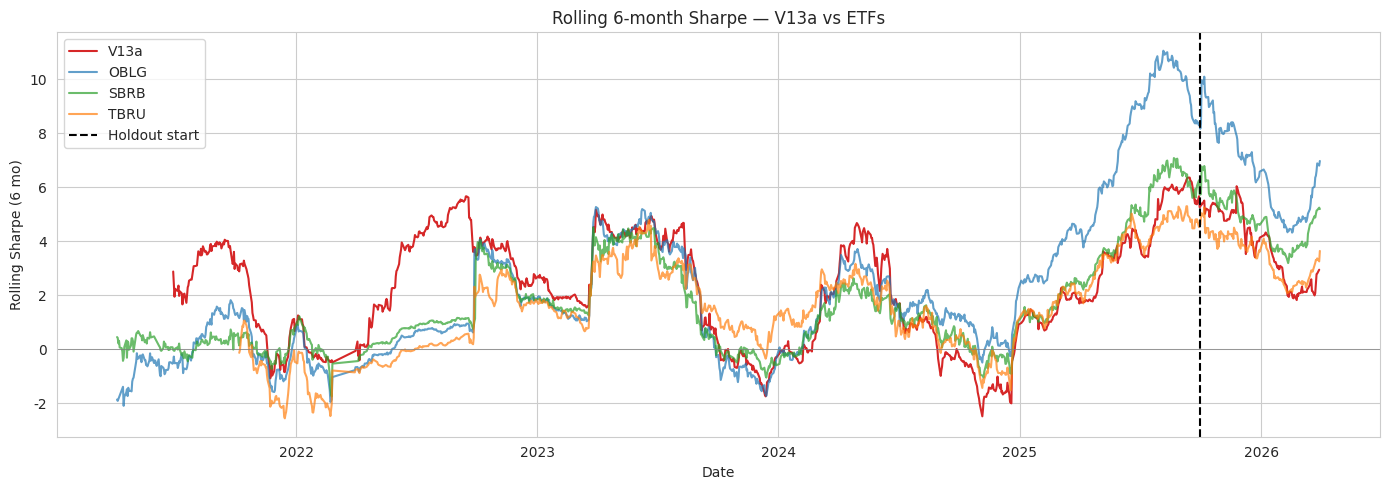

In [5]:
# Rolling 6-month Sharpe для V13a и OBLG
def rolling_sharpe(rets_df, window=126):
    r = rets_df.copy().sort_values('date').reset_index(drop=True)
    r['mean_roll'] = r['return'].rolling(window, min_periods=window // 2).mean()
    r['std_roll'] = r['return'].rolling(window, min_periods=window // 2).std()
    r['sharpe_roll'] = np.sqrt(252) * r['mean_roll'] / r['std_roll']
    return r[['date', 'sharpe_roll']]

v13a_roll = rolling_sharpe(rets_v13a)
oblg_roll = rolling_sharpe(etfs[['date', 'oblg_ret']].dropna().rename(columns={'oblg_ret': 'return'}))
sbrb_roll = rolling_sharpe(etfs[['date', 'sbrb_ret']].dropna().rename(columns={'sbrb_ret': 'return'}))
tbru_roll = rolling_sharpe(etfs[['date', 'tbru_ret']].dropna().rename(columns={'tbru_ret': 'return'}))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(v13a_roll['date'], v13a_roll['sharpe_roll'], color='tab:red', label='V13a', linewidth=1.5)
ax.plot(oblg_roll['date'], oblg_roll['sharpe_roll'], color='tab:blue', label='OBLG', alpha=0.7)
ax.plot(sbrb_roll['date'], sbrb_roll['sharpe_roll'], color='tab:green', label='SBRB', alpha=0.7)
ax.plot(tbru_roll['date'], tbru_roll['sharpe_roll'], color='tab:orange', label='TBRU', alpha=0.7)
ax.axvline(sl.MAIN_END, color='black', linestyle='--', label='Holdout start')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_title('Rolling 6-month Sharpe — V13a vs ETFs')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe (6 mo)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '13c_rolling_sharpe.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 6. Сохранение

In [6]:
df.to_csv(sl.DATA_DIR / 'nb13c_windows_metrics.csv', index=False)
wins_df.to_csv(sl.DATA_DIR / 'nb13c_wins_matrix.csv', index=False)
print('Saved: nb13c_windows_metrics.csv, nb13c_wins_matrix.csv')

Saved: nb13c_windows_metrics.csv, nb13c_wins_matrix.csv


## Часть 7. Итоги

**Что покажет анализ:**
- Если V13a побеждает в окнах с stress events (W2, possibly W7) — overlay работает
- Если проигрывает в bull markets (W10) — strategy не для всех режимов
- Cumulative pattern даёт honest картину применимости стратегии